
## Introduction

Norbert is a young painting student who is particularly fascinated by abstract art. As part of his latest experiment, he created a composition consisting of many translucent, colored circles overlapping each other. Fascinated by the final effect, Norbert began to consider the inverse problem: based on the final image, can we precisely reconstruct the parameters of all the circles that created it?

Your task is to help the young painter Norbert develop an algorithm that performs such a decomposition and finds all the parameters of the circles from which the painted image can be reconstructed.

## Task
Your main task is to write a function `solve()` located in the `YourSolution` class.
This function should, for each image, find a set of parameters `params` that describe all the colored circles forming the given image.

You have at your disposal the function `differentiable_renderer`. It takes:

- `params` (torch.Tensor) - A tensor of shape `[N, 7]`, where `N` is the number of circles, and 7 is the number of parameters per circle.
- `H` (int) - Height of the output image.
- `W` (int) - Width of the output image.

The function returns a PyTorch tensor of size `[3, H, W]`, which represents a color image composed of `N` overlapping circles. The name `differentiable_renderer` is not accidental. It means that the image creation process is mathematically "transparent" for optimization algorithms. The exact code of this function and sample images can be seen in the cells below.

Your goal is to find such parameters `params` that when using `differentiable_renderer` the resulting image is as similar as possible to the original. The measure of success will be minimizing the error between your reconstruction and the original. In other words, your goal is to find the circle parameters that, when rendered, best reproduce the input image. For each image, you must return the parameters of exactly `N` circles.

## Data

The dataset contains images generated by this function, each as a tensor of dimensions `[3, H, W]`.

Each image, both in the validation and test data, consists of `N` overlapping circles, where `N` is a constant value equal to 10. Each circle is defined by 7 parameters:

- position_X - X coordinate of the circle
- position_Y - Y coordinate of the circle
- r - radius of the circle
- color_R - red color value
- color_G - green color value
- color_B - blue color value
- alpha - transparency of the circle

You have two datasets saved in the file `train_validation_sets.npz`:

- `x_train` - 50 training images `[50, 3, H, W]`
- `x_val` - 10 validation images `[10, 3, H, W]`
- `y_train` - true circle parameters for training images `[50, N, 7]`
- `y_val` - true circle parameters for validation images `[10, N, 7]`

The test data `x_test` and `y_test`, which will be used later for the final evaluation of your solution, have shapes `[10, 3, H, W]` and `[10, N, 7]`. You do not have access to them and they are hidden on the testing platform.

## Evaluation Criterion
The quality of your solution will be evaluated using the **MSE (Mean Squared Error)** metric, which is calculated as the average of the squared differences between corresponding pixels (tensor elements) of the original and reconstructed images.

$$
\text{MSE} = \frac{1}{M} \sum_{i=1}^{M} (O_i - R_i)^2
$$

Where $M$ is the total number of elements in the tensor representing the image (in our case $M = 3 \times H \times W$). $O$ is the image from the dataset, and $R$ is the image generated from the parameters returned by the solution `R = differentiable_renderer(params, H, W)`.

A lower MSE value means better fit and higher reconstruction quality; a value of **0.0** means the images are identical.

For this task, you can score between 0 and 100 points. The result will be scaled linearly depending on the achieved **average MSE** on the entire test set:

- **Average MSE ≥ 0.02**: 0 points
- **Average MSE ≤ 0.01**: 100 points
- **Values between 0.01 and 0.02**: scaled linearly.

The final score is calculated according to the formula:
$$
\text{Points} =
\begin{cases}
0 & \text{for } \text{Average MSE} \geq 0.02 \\
100 \times \frac{0.02 - \text{Average MSE}}{0.02 - 0.01} & \text{for } 0.01 < \text{Average MSE} < 0.02 \\
100 & \text{for } \text{Average MSE} \leq 0.01
\end{cases}
$$

## Constraints

- Your solution will be tested on the Competition Platform without internet access and in an environment **without GPU**.
- The evaluation of your final solution on the Competition Platform cannot take longer than 5 minutes **without GPU**.
- List of allowed libraries: `scikit-learn`, `numpy`, `pandas`, `pytorch`.
- For each image, you must return parameters for exactly `N` circles.

## Submission Files
This notebook supplemented with your solution (see the `YourSolution` class).

## Evaluation
Remember that during testing, the `FINAL_EVALUATION_MODE` flag will be set to `True`.

For this task, you can score between 0 and 100 points. The number of points you will receive will be calculated on the (secret) test set on the Competition Platform based on the above formula, rounded to an integer. If your solution does not meet the above criteria or does not execute correctly, you will receive 0 points for the task.


# Starter Code
In this section, we initialize the environment by importing the necessary libraries and functions. The prepared code will facilitate efficient data manipulation and building the appropriate solution.

In [1]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################
FINAL_EVALUATION_MODE = False # During testing on the platform, the flag automatically changes to True.

In [2]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################
import random
import numpy as np
import torch
import torch.nn.functional as F

if not FINAL_EVALUATION_MODE:
    import matplotlib.pyplot as plt


# Setting the random seed to ensure deterministic results
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


# Global parameters for images and number of shapes, used in the task
H, W = 64, 64
N_SHAPES = 10

## Function `differentiable_renderer`
We define our `differentiable_renderer` function

In [3]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################
def differentiable_renderer(params, H, W):
    """
    Differentially renders circles onto an image based on the given parameters.

    Args:
        params (torch.Tensor): Tensor of shape [N, 7], where N is the number of circles.
                               Each row contains 7 parameters in the following order:
                               [position_X, position_Y, r, color_R, color_G, color_B, alpha]
        H (int): Height of the output image.
        W (int): Width of the output image.

    Returns:
        torch.Tensor: Rendered image as a tensor of shape [3, H, W].
    """
    sharpness = 20.0
    if params is None or params.shape[0] == 0:
        return torch.ones(3, H, W)
    N = params.shape[0]
    y_coords, x_coords = torch.meshgrid(torch.arange(H, dtype=torch.float32), torch.arange(W, dtype=torch.float32), indexing='ij')
    centers_x, centers_y = params[:, 0].view(N, 1, 1), params[:, 1].view(N, 1, 1)
    radii_sq = params[:, 2].view(N, 1, 1)**2
    colors = params[:, 3:6].view(N, 3, 1, 1)
    alphas = params[:, 6].view(N, 1, 1, 1)
    dist_sq = (x_coords - centers_x)**2 + (y_coords - centers_y)**2
    mask = torch.sigmoid((radii_sq - dist_sq) * sharpness)
    pixel_alpha = mask.unsqueeze(1) * alphas
    image = torch.ones(3, H, W)
    for i in range(N):
        image = colors[i] * pixel_alpha[i] + image * (1.0 - pixel_alpha[i])
    return image

## Loading Data
With the code below, the data will be loaded and appropriately prepared.

In [5]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################
def setup_data_from_npz(path_to_npz: str, mode: str):

    bundle_npz = np.load(path_to_npz, allow_pickle=True)
    if mode == "train":
        x_bundle_name, y_bundle_name = "X_train", "y_train"
    elif mode == "val":
        x_bundle_name, y_bundle_name = "X_validation", "y_validation"

    x = torch.from_numpy(bundle_npz[x_bundle_name]).float()
    y = torch.from_numpy(bundle_npz[y_bundle_name]).float()

    return x, y

if not FINAL_EVALUATION_MODE:
    x_train, y_train = setup_data_from_npz("train_validation_sets.npz", "train")
    x_val, y_val = setup_data_from_npz("train_validation_sets.npz", "val")

## Data Visualization

Using the `matplotlib` library, we can display sample images from the training and validation sets

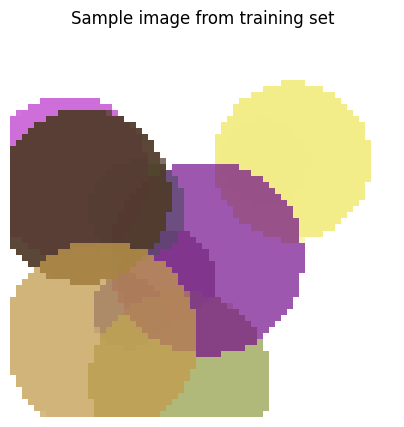

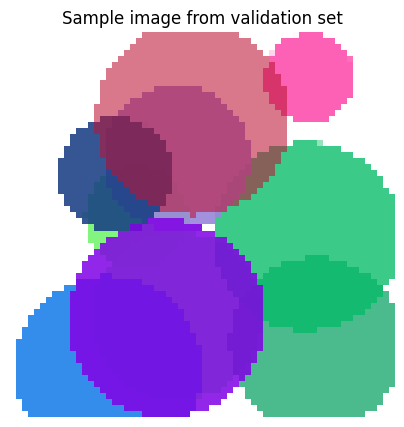

In [6]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################
import matplotlib.pyplot as plt

def display_sample(data_tensor, title="Sample image"):
    """
    Displays a single image from a PyTorch tensor.
    Matplotlib expects images in [H, W, C] format, so we need to transform the tensor from [C, H, W] format,
    where C is the number of channels (in our case 3 - RGB), H is height, and W is width of the image.
    """
    img = data_tensor.permute(1, 2, 0).numpy()
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


if not FINAL_EVALUATION_MODE:
    display_sample(x_train[0], title="Sample image from training set")
    display_sample(x_val[0], title="Sample image from validation set")

## Evaluation Criterion Code

Code similar to the one below will be used to evaluate the solution on the test set.

In [7]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################
def compute_score(mse: float) -> float:
    """
    - MSE <= 0.01 receives 100 points.
    - MSE >= 0.02 receives 0 points.
    - The result is linearly interpolated between these thresholds.
    """
    lower_bound_mse = 0.01
    upper_bound_mse = 0.02

    if mse <= lower_bound_mse:
        return 100.0
    if mse >= upper_bound_mse:
        return 0.0

    # Linear interpolation
    score = 100.0 * (upper_bound_mse - mse) / (upper_bound_mse - lower_bound_mse)
    return score


def evaluate_solution(solution, ds) -> float:
    """Evaluates the solution on the given dataset."""
    total_mse = 0.0
    for i in range(ds.shape[0]):
        target_image = ds[i]

        # Run the algorithm
        final_params = solution.solve(target_image.clone())
        assert final_params.shape == (N_SHAPES, 7), \
            f"Returned tensor has incorrect shape: {final_params.shape}, expected ({N_SHAPES}, 7)"

        # Evaluation
        final_image = differentiable_renderer(final_params, H, W)
        mse = F.mse_loss(final_image, target_image).item()
        total_mse += mse

    average_mse = total_mse / ds.shape[0]
    return average_mse


## Your Solution
In this section, you should place your solution. Make changes only here!

In [176]:
from torch import nn
class YourSolution():
    def solve(self, target_image: torch.Tensor) -> torch.Tensor:
        # params (torch.Tensor): Tensor of shape [N, 7], where N is the number of circles.
        #                        Each row contains 7 parameters in the following order:
        #                        [position_X, position_Y, r, color_R, color_G, color_B, alpha]
        # Example solution that returns random parameters for each single image
        
        EPOCHS = 3000
        params = nn.Parameter(torch.rand(N_SHAPES, 7))
        params.data[:, 0] = torch.rand(N_SHAPES) * W
        params.data[:, 1] = torch.rand(N_SHAPES) * H
        params.data[:, 2] = torch.rand(N_SHAPES) * min(H, W) / 8

        params.data[:, 3:6] = torch.rand(N_SHAPES, 3)
        params.data[:, 6] = 0.5
        optimizer = torch.optim.Adam([params], lr=1e-1)
        criterion = nn.MSELoss()

        for epoch in range(EPOCHS):
            optimizer.zero_grad()
            pred = differentiable_renderer(params, target_image.shape[1], target_image.shape[2])

            loss = criterion(pred, target_image) + 1e-4 * (params[:, 2].mean()) + 1e-5 * (params[:, 6].mean())
            loss.backward()
            optimizer.step()
            if epoch % 500 == 500-1:
                print(f'Epochs {epoch+1} | Loss: {loss.item()}')
        
        return params

In [177]:
sol = YourSolution()
sol.solve(x_val[0])

Epochs 500 | Loss: 0.026468820869922638
Epochs 1000 | Loss: 0.02619551122188568
Epochs 1500 | Loss: 0.0228283554315567
Epochs 2000 | Loss: 0.015172900632023811
Epochs 2500 | Loss: 0.017183415591716766
Epochs 3000 | Loss: 0.016437094658613205


Parameter containing:
tensor([[ 3.3774e+01,  5.3247e+01,  9.5771e+00,  6.2952e-02, -5.9122e-01,
          7.0322e-01,  4.6028e-01],
        [ 4.9528e+01,  6.9680e+00,  7.2118e+00,  9.7117e-01, -1.1772e+00,
         -3.3306e-02,  9.5436e-01],
        [ 4.3224e+01,  5.0671e+00,  3.2104e+00,  1.0018e+00, -1.1926e+00,
          3.4497e-03,  3.0712e-01],
        [ 2.9979e+01,  2.6644e+01, -2.1538e+01,  3.5425e-01,  2.0701e-01,
          7.1339e-01,  8.9590e-01],
        [ 6.2410e+01, -9.3716e+00, -3.8136e+01,  9.9924e-01,  9.8409e-01,
          9.9512e-01,  7.0486e-01],
        [ 5.8394e+01,  5.3400e+01,  1.9006e+01,  1.5532e-01,  6.7318e-01,
          4.6804e-01,  8.5372e-01],
        [ 5.0829e+01,  2.5335e+01, -1.1655e+01,  9.1664e-01,  9.9703e-01,
          9.2443e-01,  4.3673e-01],
        [ 5.0159e+01,  3.1841e+01, -1.3663e+01,  1.3383e-01,  7.7816e-01,
          4.7064e-01,  8.8688e-01],
        [ 2.9849e+01,  1.3919e+01,  1.5992e+01,  7.5084e-01,  2.3096e-01,
          3.1289e-01,  6

# Evaluation

Running the cell below will allow you to check how many points your solution would score on the validation data. Before submitting, make sure that the entire notebook runs from start to finish without errors and without requiring user intervention after selecting the "Run All" option.

In [178]:
######################### DO NOT CHANGE THIS CELL WHEN SUBMITTING ##########################
if not FINAL_EVALUATION_MODE:
    your_solution = YourSolution()
    criterion = evaluate_solution(your_solution, x_val)
    score = compute_score(criterion)
    print("Evaluation of model performance on the validation set for YourSolution:")
    print(f"Mean Squared Error (MSE): {criterion: .6f}")
    print(f"Score: {score} points")


Epochs 500 | Loss: 0.0134941590949893
Epochs 1000 | Loss: 0.012597814202308655
Epochs 1500 | Loss: 0.011969150975346565
Epochs 2000 | Loss: 0.012251375243067741
Epochs 2500 | Loss: 0.012030845507979393
Epochs 3000 | Loss: 0.012222825549542904
Epochs 500 | Loss: 0.01761854626238346
Epochs 1000 | Loss: 0.013151331804692745
Epochs 1500 | Loss: 0.012221353128552437
Epochs 2000 | Loss: 0.012590762227773666
Epochs 2500 | Loss: 0.011110581457614899
Epochs 3000 | Loss: 0.011383851990103722
Epochs 500 | Loss: 0.03216409310698509
Epochs 1000 | Loss: 0.019512979313731194
Epochs 1500 | Loss: 0.01788567192852497
Epochs 2000 | Loss: 0.015116898342967033
Epochs 2500 | Loss: 0.015199010260403156
Epochs 3000 | Loss: 0.01509785931557417
Epochs 500 | Loss: 0.014176281169056892
Epochs 1000 | Loss: 0.011508592404425144
Epochs 1500 | Loss: 0.011090208776295185
Epochs 2000 | Loss: 0.009806430898606777
Epochs 2500 | Loss: 0.00877202209085226
Epochs 3000 | Loss: 0.008111312054097652
Epochs 500 | Loss: 0.010945